# Two-locus one-trait (2)

Question:



In [1]:
import numpy as np
from scipy.stats import norm, gaussian_kde
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from itertools import product
import hanoi
import pandas as pd
from scipy import stats

In [2]:
n=1
L=2
N=100

In [3]:
colors = cm.tab10.colors

## 1. $\alpha < \mu_0 < \mu_1$

In [4]:
m0 = 1.1
m1 = 1.9
v0 = 0.1
v1 = 1.0

In [5]:
M_m = np.array([[m1 - m0, 0]])
M_v = np.array([[0, v1 - v0]])
z_ref = np.array([m0])
c_ref = np.array([[v0]])

In [6]:
M = hanoi.MutEffect(mean = M_m, var = M_v, cov=np.array([[]]))

In [7]:
rng = np.random.default_rng()
G = rng.permutation(np.repeat([0,1,2], [25, 50, 25]).astype(float).reshape((1,100)).repeat(2, axis = 0), axis = 1)


In [8]:
G

array([[1., 1., 1., 1., 2., 1., 2., 0., 0., 2., 0., 1., 0., 2., 0., 1.,
        0., 1., 2., 1., 1., 1., 2., 2., 1., 1., 0., 2., 2., 1., 2., 1.,
        1., 1., 0., 1., 0., 0., 2., 1., 0., 0., 1., 0., 2., 0., 1., 1.,
        2., 2., 2., 1., 1., 1., 0., 2., 1., 1., 1., 2., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 1., 2., 1., 0., 1., 1., 2., 1., 2., 0., 1.,
        1., 2., 2., 0., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 2., 0.,
        2., 2., 1., 1.],
       [1., 1., 1., 1., 2., 1., 2., 0., 0., 2., 0., 1., 0., 2., 0., 1.,
        0., 1., 2., 1., 1., 1., 2., 2., 1., 1., 0., 2., 2., 1., 2., 1.,
        1., 1., 0., 1., 0., 0., 2., 1., 0., 0., 1., 0., 2., 0., 1., 1.,
        2., 2., 2., 1., 1., 1., 0., 2., 1., 1., 1., 2., 1., 0., 0., 0.,
        1., 1., 1., 1., 1., 1., 2., 1., 0., 1., 1., 2., 1., 2., 0., 1.,
        1., 2., 2., 0., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 2., 0.,
        2., 2., 1., 1.]])

Visualise phenotype distributions

In [9]:
z = np.linspace(0, 5, 500)

In [10]:
p_00_00 = stats.norm.pdf(z, loc = m0, scale = v0) / 4
p_00_11 = stats.norm.pdf(z, loc = m0, scale = v1) / 4
p_11_00 = stats.norm.pdf(z, loc = m1, scale = v0) / 4
p_11_11 = stats.norm.pdf(z, loc = m1, scale = v1) / 4

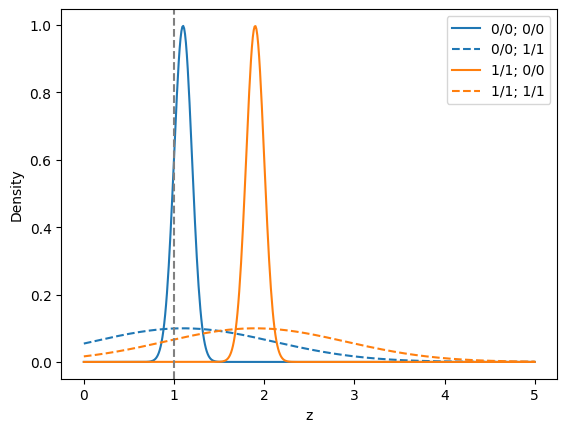

In [11]:
plt.plot(z, p_00_00, color = colors[0], linestyle = "-", label = "0/0; 0/0")
plt.plot(z, p_00_11, color = colors[0], linestyle = "--", label = "0/0; 1/1")
plt.plot(z, p_11_00, color = colors[1], linestyle = "-", label = "1/1; 0/0")
plt.plot(z, p_11_11, color = colors[1], linestyle = "--", label = "1/1; 1/1")
plt.axvline(x = 1, linestyle = "--", color = "gray")
plt.legend()
plt.xlabel("z")
plt.ylabel("Density")
plt.show()

In [12]:
res = hanoi.run_replicates(n_reps = 100, 
                               n_gen = 0, 
                               genotype = G, 
                               mut_effect = M, 
                               record = True, 
                               mut_rate = 0.0, 
                               mean_0 = z_ref,
                               varcov_0 = c_ref, 
                               fit_func = "fit_step",
                               boxes = np.array([[[1], [np.inf]]])
                         )


In [13]:
allele_freqs = [res_i.allele_freqs_all().tolist() for res_i in res]

In [14]:
len(allele_freqs)

100

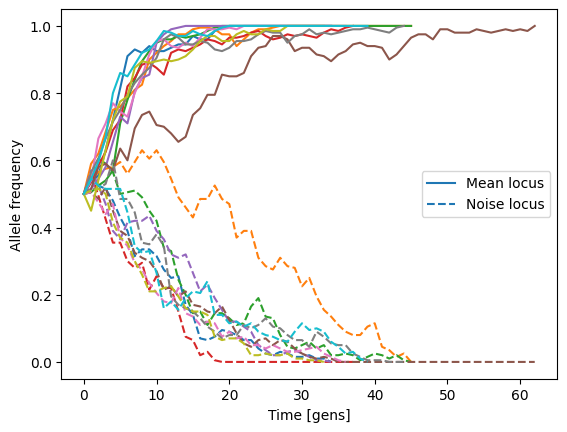

In [15]:
for i, arr in enumerate(allele_freqs):
    if i < 10:
        a = np.array(arr)
        line, = plt.plot(a[:, 0], label='Mean locus' if i == 0 else '_' )
        plt.plot(a[:, 1], linestyle='--', color = line.get_color(), label='Noise locus' if i == 0 else '_')

plt.legend()
plt.xlabel("Time [gens]")
plt.ylabel("Allele frequency")
plt.show()

Get T_fix of both loci

In [16]:
t_fix = np.array([np.argmax((res_i.allele_freqs_all() == 0) | (res_i.allele_freqs_all() == 1), axis = 0) for res_i in res])

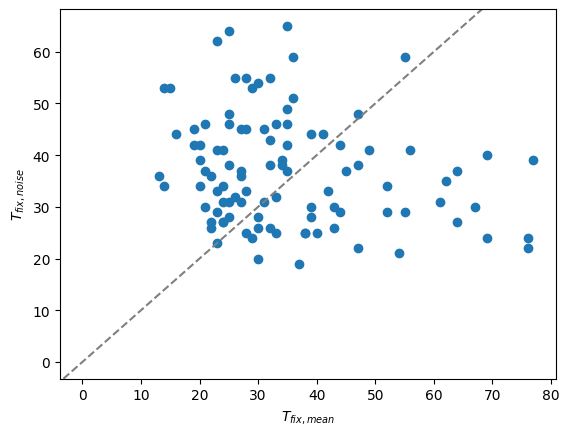

In [17]:
plt.scatter(t_fix[:,0], t_fix[:,1])

plt.xlabel("$T_{fix, mean}$")
plt.ylabel("$T_{fix, noise}$")
# y=x line
plt.axline((0,0), slope=1, color = "gray", linestyle = "--")

plt.show()

In [18]:
stats.pearsonr(t_fix[:,0], t_fix[:,1])

PearsonRResult(statistic=np.float64(-0.2221741711308874), pvalue=np.float64(0.02630671286252689))

In [19]:
t_fix.shape

(100, 2)

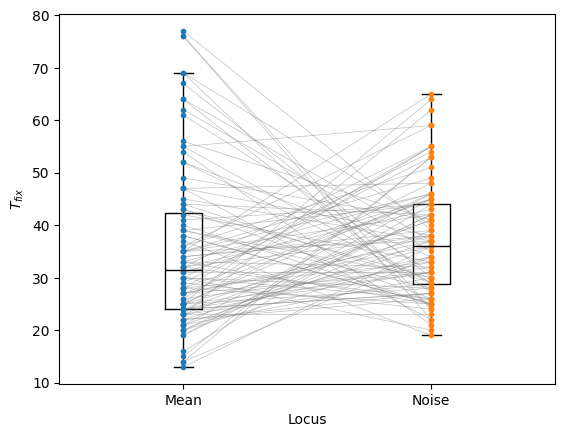

In [20]:
fig, ax = plt.subplots()

ax.boxplot([t_fix[:,0], t_fix[:,1]], 
           tick_labels=["Mean", "Noise"], 
           medianprops=dict(color='black'),
           showfliers=False
          )
for i in range(t_fix.shape[0]):
    plt.plot([1,2], t_fix[i,:],
             color = "gray",
             alpha = 0.5,
             linewidth = 0.5
            )
plt.plot([1]*t_fix.shape[0], t_fix[:,0], 'o', markersize = 3)
plt.plot([2]*t_fix.shape[0], t_fix[:,1], 'o', markersize = 3)
plt.xlabel("Locus")    
plt.ylabel("$T_{fix}$")    
plt.show()

Paired t-test

In [21]:
t_stat, p_val = stats.ttest_rel(t_fix[:,0], t_fix[:,1])

In [22]:
p_val

np.float64(0.34462328438693546)

<>:53: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8382/2031690800.py:53: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle(f"$(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = {m0, m1, v0, v1}$", fontsize=14)


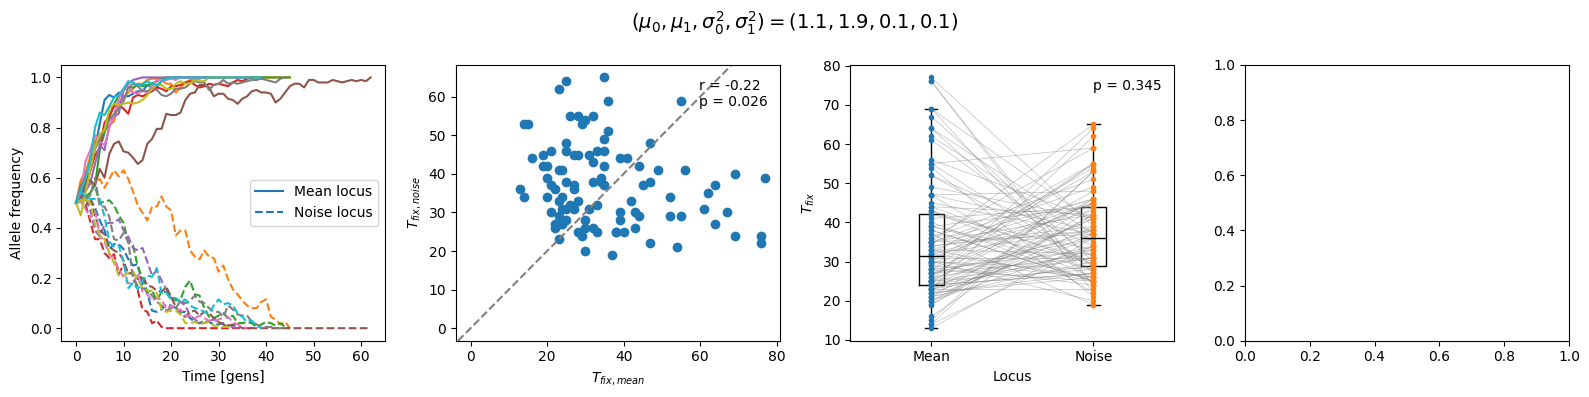

In [28]:
fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize=  (16,4))

# Panel of allele freq trajectory
for i, arr in enumerate(allele_freqs):
    if i < 10:
        a = np.array(arr)
        line, = axes[0].plot(a[:, 0], label='Mean locus' if i == 0 else '_' )
        axes[0].plot(a[:, 1], linestyle='--', color = line.get_color(), label='Noise locus' if i == 0 else '_')
axes[0].legend()
axes[0].set_xlabel("Time [gens]")
axes[0].set_ylabel("Allele frequency")

# Panel of T_fix scatter
t_fix = np.array([np.argmax((res_i.allele_freqs_all() == 0) | (res_i.allele_freqs_all() == 1), axis = 0) for res_i in res])
axes[1].scatter(t_fix[:,0], t_fix[:,1])
# y=x line
axes[1].axline((0,0), slope=1, color = "gray", linestyle = "--")

axes[1].set_xlabel("$T_{fix, mean}$")
axes[1].set_ylabel("$T_{fix, noise}$")


r, p = stats.pearsonr(t_fix[:,0], t_fix[:,1])

axes[1].text(0.75, 0.95, f"r = {r:.2f}\np = {p:.3f}",
        transform=axes[1].transAxes,   # coordinates relative to axes (0-1)
        verticalalignment='top',
        fontsize=10)

# Panel of T_fix box
axes[2].boxplot([t_fix[:,0], t_fix[:,1]], 
           tick_labels=["Mean", "Noise"], 
           medianprops=dict(color='black'),
           showfliers=False
          )
for i in range(t_fix.shape[0]):
    axes[2].plot([1,2], t_fix[i,:],
             color = "gray",
             alpha = 0.5,
             linewidth = 0.5
            )
axes[2].plot([1]*t_fix.shape[0], t_fix[:,0], 'o', markersize = 3)
axes[2].plot([2]*t_fix.shape[0], t_fix[:,1], 'o', markersize = 3)
axes[2].set_xlabel("Locus")    
axes[2].set_ylabel("$T_{fix}$")    
# p-val
t, p = stats.ttest_rel(t_fix[:,0], t_fix[:,1])
axes[2].text(0.75, 0.95, f"p = {p:.3f}",
        transform=axes[2].transAxes,   # coordinates relative to axes (0-1)
        verticalalignment='top',
        fontsize=10)

fig.suptitle(f"$(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = {m0, m1, v0, v1}$", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
rng.permuted(np.repeat([0,1,2], [25, 50, 25]).astype(float).reshape((1,100)).repeat(2, axis = 0), axis = 1)

array([[2., 0., 1., 1., 1., 1., 1., 1., 2., 2., 1., 1., 2., 2., 0., 0.,
        1., 1., 1., 0., 1., 2., 2., 2., 1., 1., 1., 1., 2., 0., 2., 2.,
        0., 2., 1., 1., 0., 1., 1., 1., 0., 2., 2., 1., 2., 0., 1., 1.,
        0., 0., 1., 1., 1., 2., 1., 1., 1., 0., 2., 1., 1., 1., 2., 2.,
        1., 2., 0., 0., 0., 0., 1., 1., 0., 0., 1., 2., 0., 2., 1., 0.,
        1., 0., 1., 1., 1., 1., 2., 0., 1., 1., 1., 0., 0., 2., 1., 1.,
        1., 0., 2., 1.],
       [2., 0., 0., 1., 1., 1., 2., 1., 1., 1., 1., 1., 2., 2., 1., 2.,
        0., 2., 0., 0., 0., 1., 0., 0., 1., 2., 1., 1., 2., 1., 2., 1.,
        1., 2., 1., 1., 1., 0., 1., 1., 2., 0., 2., 1., 1., 2., 0., 0.,
        0., 2., 0., 1., 1., 2., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.,
        2., 0., 1., 2., 2., 0., 1., 1., 2., 1., 2., 0., 1., 2., 1., 1.,
        1., 2., 1., 2.]])

In [30]:
m0 = 1.1
m1 = 1.9
v0 = 0.1
v1 = 0.1 

In [31]:
rng = np.random.default_rng()
rng.permuted(np.vstack([np.repeat([0,1,2], [81, 18, 1]).astype(float), np.repeat([0,1,2], [25, 50, 25]).astype(float)]), axis =1)

array([[1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 2., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        1., 1., 0., 0.],
       [1., 1., 1., 0., 0., 1., 2., 2., 0., 1., 1., 0., 0., 2., 1., 1.,
        1., 0., 0., 1., 2., 0., 1., 1., 2., 2., 2., 1., 2., 1., 2., 1.,
        0., 1., 1., 1., 1., 1., 2., 1., 1., 2., 2., 1., 0., 0., 1., 1.,
        0., 0., 2., 2., 2., 1., 1., 1., 2., 2., 2., 1., 0., 1., 1., 2.,
        1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 2., 1., 1., 2.,
        1., 2., 0., 2., 0., 1., 0., 0., 2., 1., 1., 2., 0., 0., 0., 0.,
        1., 1., 1., 1.]])

In [32]:
rng.permutation(np.repeat([0,1,2], [25, 50, 25]).astype(float).reshape((1,100)).repeat(2, axis = 0), axis = 1)

array([[1., 1., 1., 2., 1., 1., 0., 1., 1., 0., 1., 1., 2., 2., 0., 2.,
        0., 0., 1., 1., 2., 2., 2., 1., 0., 2., 0., 1., 1., 1., 0., 1.,
        1., 1., 0., 1., 2., 0., 0., 0., 1., 1., 2., 1., 1., 1., 0., 1.,
        1., 2., 1., 0., 0., 1., 0., 2., 2., 1., 2., 1., 1., 1., 0., 1.,
        1., 1., 1., 0., 1., 1., 2., 2., 2., 2., 1., 0., 1., 2., 1., 2.,
        2., 0., 1., 1., 0., 0., 2., 1., 0., 2., 1., 0., 1., 2., 1., 1.,
        2., 1., 1., 0.],
       [1., 1., 1., 2., 1., 1., 0., 1., 1., 0., 1., 1., 2., 2., 0., 2.,
        0., 0., 1., 1., 2., 2., 2., 1., 0., 2., 0., 1., 1., 1., 0., 1.,
        1., 1., 0., 1., 2., 0., 0., 0., 1., 1., 2., 1., 1., 1., 0., 1.,
        1., 2., 1., 0., 0., 1., 0., 2., 2., 1., 2., 1., 1., 1., 0., 1.,
        1., 1., 1., 0., 1., 1., 2., 2., 2., 2., 1., 0., 1., 2., 1., 2.,
        2., 0., 1., 1., 0., 0., 2., 1., 0., 2., 1., 0., 1., 2., 1., 1.,
        2., 1., 1., 0.]])

In [33]:
def sim(m0, m1, v0, v1, n_reps = 100):
    M_m = np.array([[m1 - m0, 0]])
    M_v = np.array([[0, v1 - v0]])
    z_ref = np.array([m0])
    c_ref = np.array([[v0]])
    M = hanoi.MutEffect(mean = M_m, var = M_v, cov=np.array([[]]))
    rng = np.random.default_rng()
    G = rng.permuted(np.repeat([0,1,2], [25, 50, 25]).astype(float).reshape((1,100)).repeat(2, axis = 0), axis = 1)
    #G = rng.permuted(np.vstack([np.repeat([0,1,2], [81, 18, 1]).astype(float), np.repeat([0,1,2], [25, 50, 25]).astype(float)]), axis =1)
    #G = np.repeat([0,1,2], [25, 50, 25]).astype(float).reshape((1,100)).repeat(2, axis = 0)
    res = hanoi.run_replicates(n_reps = n_reps, 
                                   n_gen = 0, 
                                   genotype = G, 
                                   mut_effect = M, 
                                   record = True, 
                                   mut_rate = 0.0, 
                                   mean_0 = z_ref,
                                   varcov_0 = c_ref, 
                                   fit_func = "fit_step",
                                   boxes = np.array([[[1], [np.inf]]])
                              )
    return res

In [34]:
def plot_res(res, m0, m1, v0, v1, n_lines, savefig):
    colors = cm.tab10.colors
    fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize=  (12,8))
    axes[1,2].set_visible(False)    
    
    # Panel of phenotype distribution
    p_00_00 = stats.norm.pdf(z, loc = m0, scale = np.sqrt(v0)) / 4
    p_00_11 = stats.norm.pdf(z, loc = m0, scale = np.sqrt(v1)) / 4
    p_11_00 = stats.norm.pdf(z, loc = m1, scale = np.sqrt(v0)) / 4
    p_11_11 = stats.norm.pdf(z, loc = m1, scale = np.sqrt(v1)) / 4
    axes[0,0].plot(z, p_00_00, color = colors[0], linestyle = "-", label = "0/0; 0/0")
    axes[0,0].plot(z, p_00_11, color = colors[0], linestyle = "--", label = "0/0; 1/1")
    axes[0,0].plot(z, p_11_00, color = colors[1], linestyle = "-", label = "1/1; 0/0")
    axes[0,0].plot(z, p_11_11, color = colors[1], linestyle = "--", label = "1/1; 1/1")
    axes[0,0].axvline(x = 1, linestyle = "--", color = "gray")
    axes[0,0].legend()
    axes[0,0].set_xlabel("z")
    axes[0,0].set_ylabel("Density")

    allele_freqs = [res_i.allele_freqs_all().tolist() for res_i in res]
    # Panel of allele freq trajectory
    for i, arr in enumerate(allele_freqs):
        if i < n_lines:
            a = np.array(arr)
            line, = axes[0,1].plot(a[:, 0], label='Mean locus' if i == 0 else '_' )
            axes[0,1].plot(a[:, 1], linestyle='--', color = line.get_color(), label='Noise locus' if i == 0 else '_')
    axes[0,1].legend()
    axes[0,1].set_xlabel("Time [gens]")
    axes[0,1].set_ylabel("Allele frequency")

    # Panel of allele freq trajectory (q0-q1)
    for i, res_i in enumerate(res):
        if i < n_lines:
            axes[0,2].plot(res_i.allele_freqs()[:,0], res_i.allele_freqs()[:,1], marker = "o")
    axes[0,2].set_xlim([-0.05,1.05])
    axes[0,2].set_ylim([-0.05, 1.05])
    axes[0,2].set_xlabel("$q_{mean}$")
    axes[0,2].set_ylabel("$q_{noise}$")

    
    # Panel of T_fix scatter
    t_fix = np.array([np.argmax((res_i.allele_freqs_all() == 0) | (res_i.allele_freqs_all() == 1), axis = 0) for res_i in res])
    axes[1,0].scatter(t_fix[:,0], t_fix[:,1])
    # y=x line
    axes[1,0].axline((0,0), slope=1, color = "gray", linestyle = "--")
    axes[1,0].set_xlabel("$T_{fix, mean}$")
    axes[1,0].set_ylabel("$T_{fix, noise}$")
    
    
    r, p = stats.pearsonr(t_fix[:,0], t_fix[:,1])
    
    axes[1,0].text(0.75, 0.95, f"r = {r:.2f}\np = {p:.3f}",
            transform=axes[1,0].transAxes,   # coordinates relative to axes (0-1)
            verticalalignment='top',
            fontsize=10)
    
    # Panel of T_fix box
    axes[1,1].boxplot([t_fix[:,0], t_fix[:,1]], 
               tick_labels=["Mean", "Noise"], 
               medianprops=dict(color='black'),
               showfliers=False
              )
    for i in range(t_fix.shape[0]):
        axes[1,1].plot([1,2], t_fix[i,:],
                 color = "gray",
                 alpha = 0.5,
                 linewidth = 0.5
                )
    axes[1,1].plot([1]*t_fix.shape[0], t_fix[:,0], 'o', markersize = 3, color = colors[0])
    axes[1,1].plot([2]*t_fix.shape[0], t_fix[:,1], 'o', markersize = 3, color = colors[0])
    axes[1,1].set_xlabel("Locus")    
    axes[1,1].set_ylabel("$T_{fix}$")    
    # p-val
    t, p = stats.ttest_rel(t_fix[:,0], t_fix[:,1])
    axes[1,1].text(0.75, 0.95, f"p = {p:.3f}",
            transform=axes[1,1].transAxes,   # coordinates relative to axes (0-1)
            verticalalignment='top',
            fontsize=10)
    
    fig.suptitle(f"$(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = {m0, m1, v0, v1}$", fontsize=14)
    plt.tight_layout()
    if savefig:
        plt.savefig(f"m0_{m0}_m1_{m1}_v0_{v0}_v1_{v1}.pdf")
    plt.show()

<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_8382/377420100.py:80: SyntaxWarning: invalid escape sequence '\m'
  fig.suptitle(f"$(\mu_0, \mu_1, \sigma_0^2, \sigma_1^2) = {m0, m1, v0, v1}$", fontsize=14)


In [35]:
def sim_plot(m0, m1, v0, v1, savefig = False, n_lines = 7, n_reps = 100):
    res = sim(m0 = m0,
          m1 = m1,
          v0 = v0,
          v1 = v1
         )
    plot_res(res = res, 
             m0 = m0, 
             m1 = m1,
             v0 = v0,
             v1 = v1,
             n_lines = n_lines,
             savefig = savefig
            )
    return res



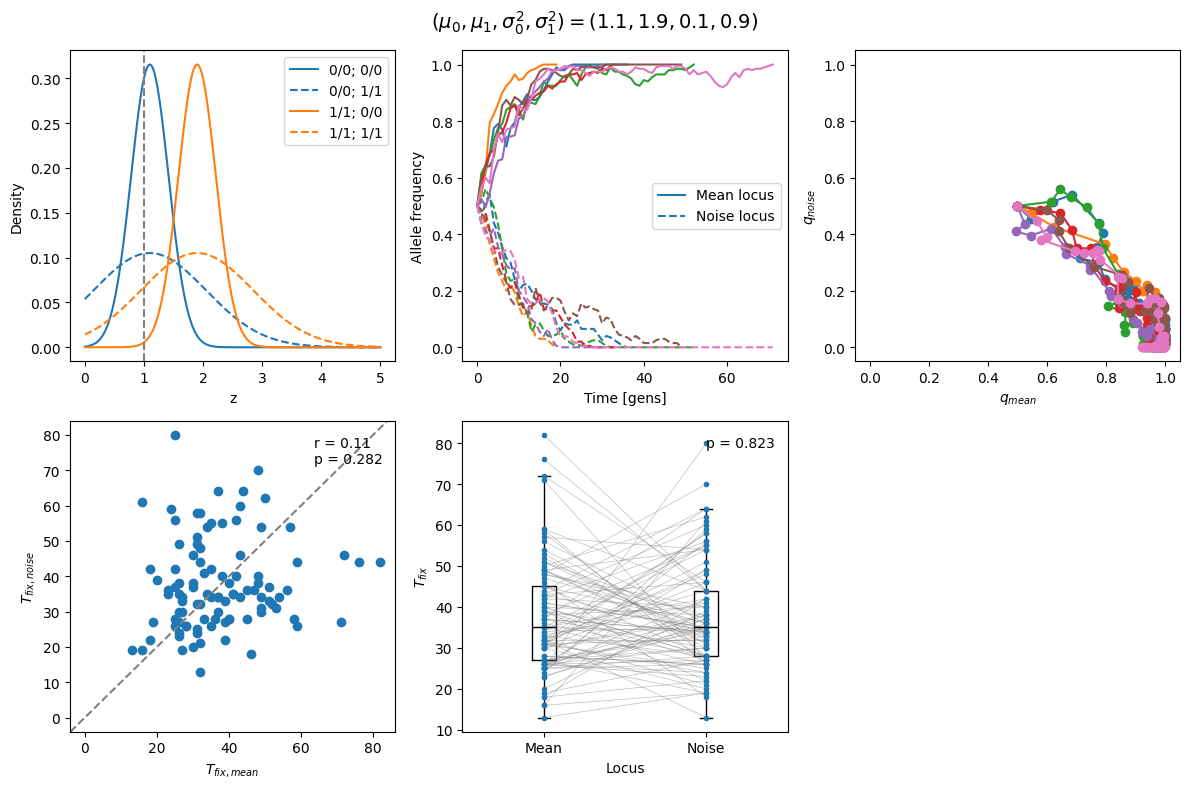

In [40]:
sim_plot(m0 = 1.1,
         m1 = 1.9,
         v0 = 0.1,
         v1 = 0.9,
         n_lines = 7,
         savefig=True
        )
plt.show()

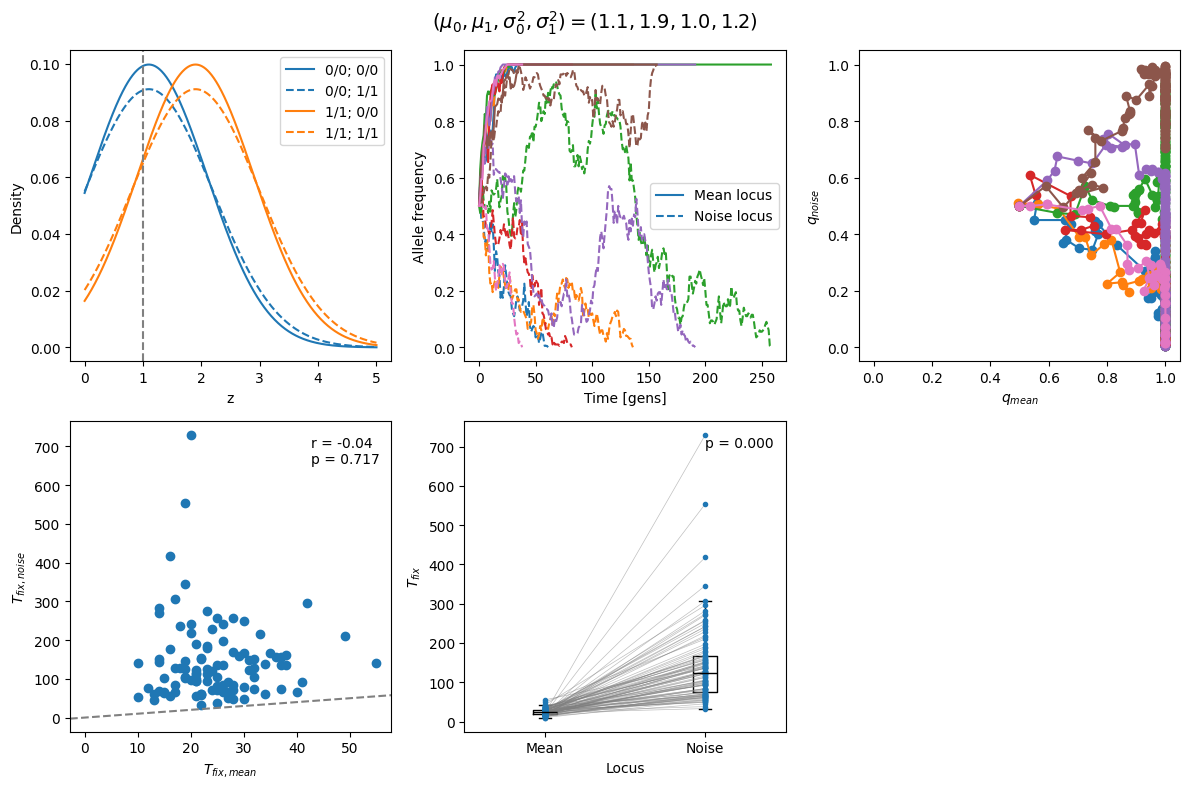

In [41]:
sim_plot(m0 = 1.1,
         m1 = 1.9,
         v0 = 1.0,
         v1 = 1.2,
         n_lines = 7,
         savefig=True
        )
plt.show()

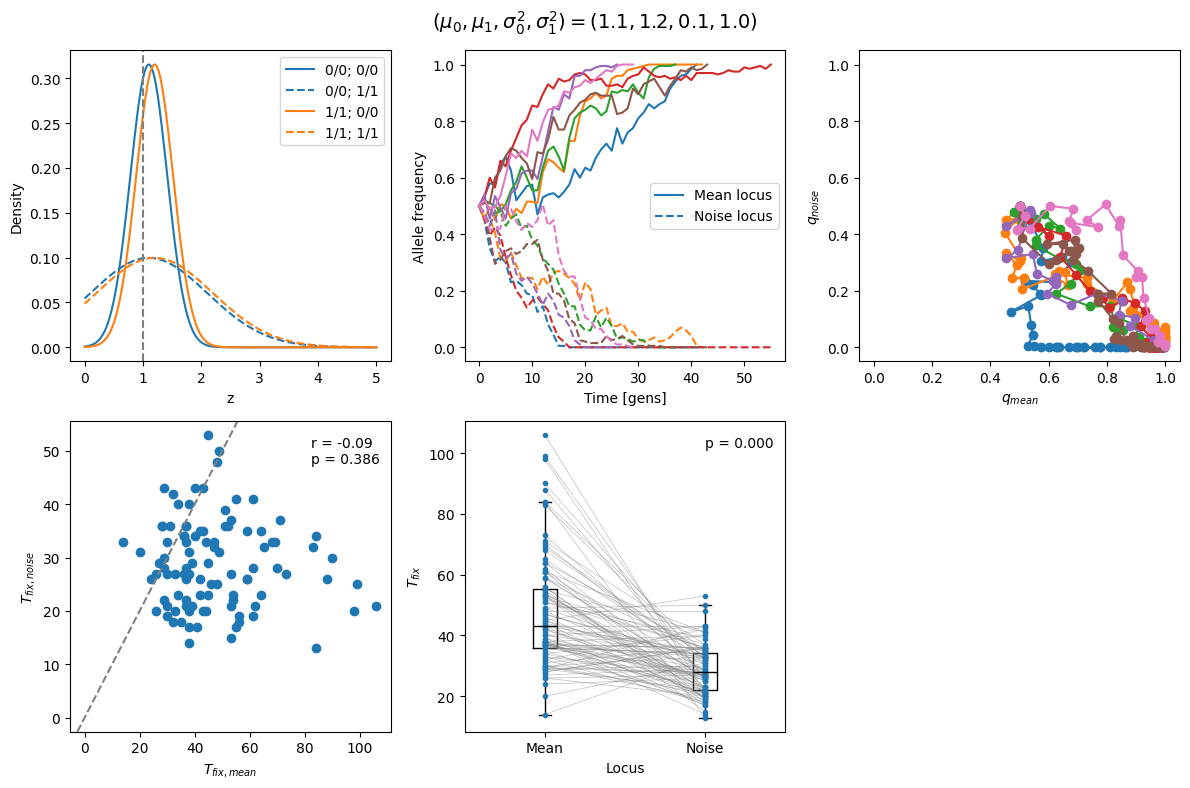

In [39]:
sim_plot(m0 = 1.1,
         m1 = 1.2,
         v0 = 0.1,
         v1 = 1.0,
         n_lines = 7,
         savefig=True
        )
plt.show()

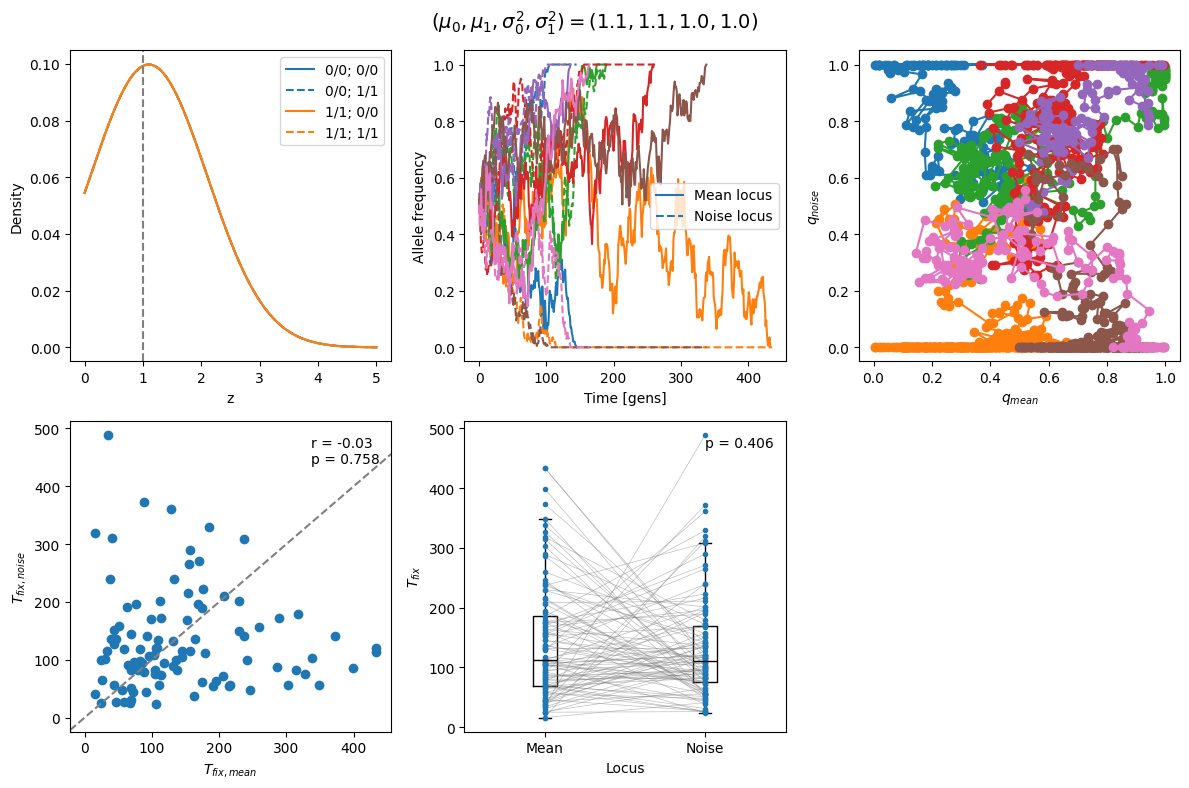

In [42]:
sim_plot(m0 = 1.1,
         m1 = 1.1,
         v0 = 1.0,
         v1 = 1.0,
         n_lines = 7,
         savefig=True
        )
plt.show()

## 2. $\mu_0 < \alpha < \mu_1$ 

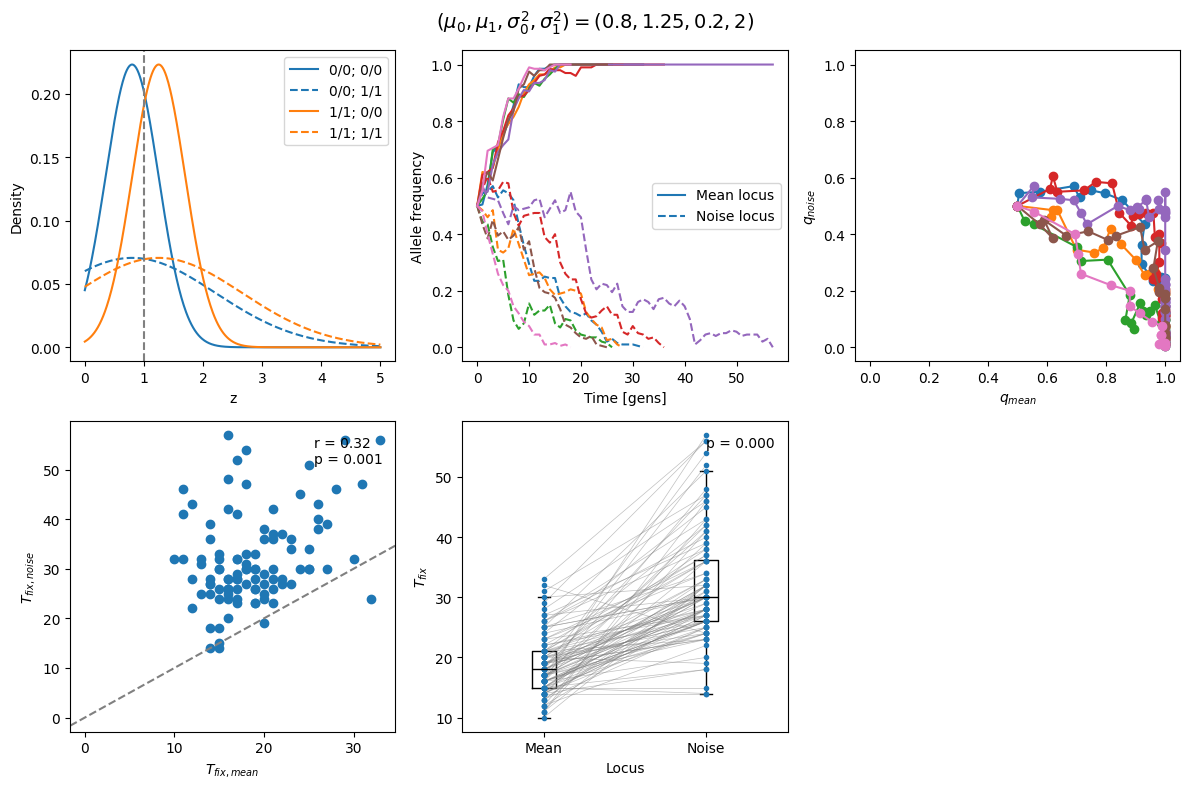

In [43]:
res_2 = sim_plot(m0 = 0.8,
         m1 = 1.25,
         v0 = 0.2,
         v1 = 2,
         n_lines = 7,
         savefig=True
        )
plt.show()

The positive correlation of $T_{fix, mean}$ and $T_{fix, noise}$ is interesting.

My interpretation is, at the mean locus, allele 1 is beneficial irrespective of the genotype at the noise locus, while at the noise locus whether allele 1 is beneficial (compared to allele 0) depends on the genotype at the mean locus.
So selection at the noise locus is slow until mean locus fixes, after which the selection on noise accelerates.

In [44]:
r_list = [stats.pearsonr(genotype_i[0], genotype_i[1]) for genotype_i in res_2[0].genotype]

/tmp/ipykernel_8382/1367521111.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_list = [stats.pearsonr(genotype_i[0], genotype_i[1]) for genotype_i in res_2[0].genotype]


In [45]:
cor_res = [np.array([[r.statistic.tolist(), r.pvalue.tolist()] for r in [stats.pearsonr(genotype_i[0], genotype_i[1]) for genotype_i in res_i.genotype]]) for res_i in res_2]

/tmp/ipykernel_8382/738422163.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  cor_res = [np.array([[r.statistic.tolist(), r.pvalue.tolist()] for r in [stats.pearsonr(genotype_i[0], genotype_i[1]) for genotype_i in res_i.genotype]]) for res_i in res_2]


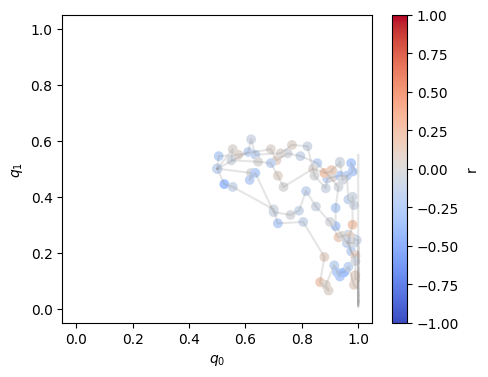

In [46]:
plt.figure(figsize = [5,4])
for i, res_i in enumerate(res_2):
    if i < 5:
        plt.plot(res_i.allele_freqs()[:,0], res_i.allele_freqs()[:,1], 
                 color = "gray", 
                 alpha = 0.2
                )
        plt.scatter(res_i.allele_freqs()[:,0], res_i.allele_freqs()[:,1], 
                    c = cor_res[i][:,0], 
                    cmap='coolwarm',
                    vmin = -1,
                    vmax = 1
                   )
cbar = plt.colorbar()
cbar.set_label("r")
plt.xlim([-0.05,1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("$q_0$")
plt.ylabel("$q_1$")
plt.savefig("m0_0.8_m1_1.25_v0_0.2_v1_2_r.pdf")
plt.show()

## 3. $\mu_0 < \mu_1 < \alpha$

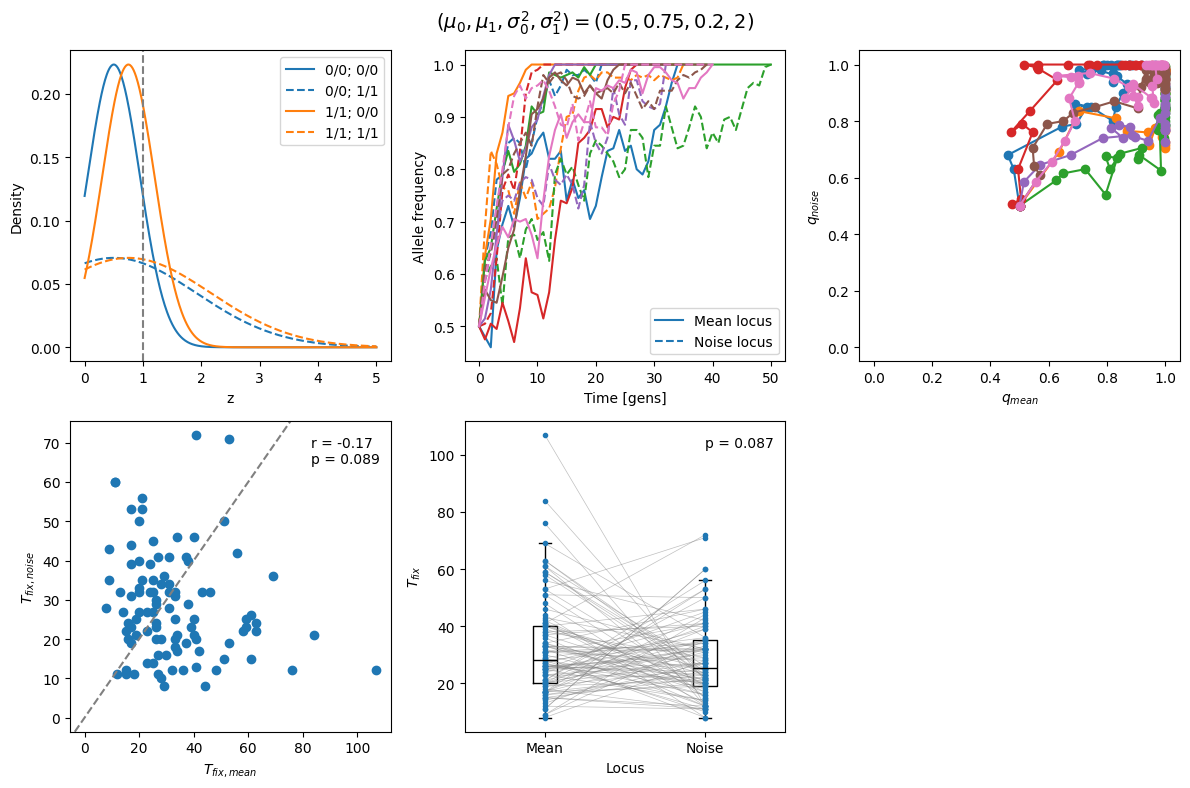

In [47]:
sim_plot(m0 = 0.5,
         m1 = 0.75,
         v0 = 0.2,
         v1 = 2,
         n_lines = 7,
         savefig = True
        )
plt.show()

In [60]:
z = np.linspace(-2,5,700)
m0 = 0.1
m1 = 1.9
v0 = 0.2
v1 = 1

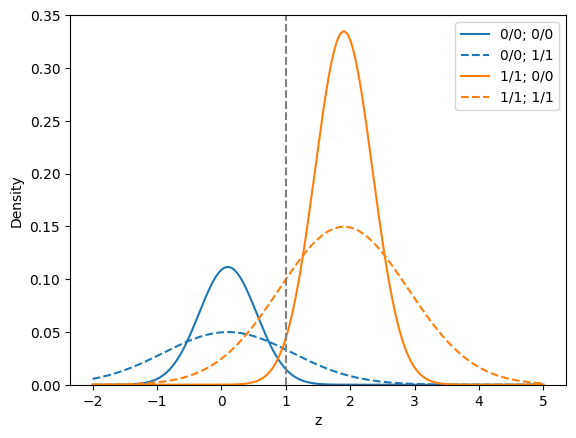

In [67]:
p_00_00 = stats.norm.pdf(z, loc = m0, scale = np.sqrt(v0)) / 8
p_00_11 = stats.norm.pdf(z, loc = m0, scale = np.sqrt(v1)) / 8
p_11_00 = 3 * stats.norm.pdf(z, loc = m1, scale = np.sqrt(v0)) / 8 
p_11_11 = 3 * stats.norm.pdf(z, loc = m1, scale = np.sqrt(v1)) / 8
plt.plot(z, p_00_00, color = colors[0], linestyle = "-", label = "0/0; 0/0")
plt.plot(z, p_00_11, color = colors[0], linestyle = "--", label = "0/0; 1/1")
plt.plot(z, p_11_00, color = colors[1], linestyle = "-", label = "1/1; 0/0")
plt.plot(z, p_11_11, color = colors[1], linestyle = "--", label = "1/1; 1/1")
plt.axvline(x = 1, linestyle = "--", color = "gray")
plt.legend()
plt.xlabel("z")
plt.ylabel("Density")
plt.ylim(0, 0.35)
plt.savefig("m0_0.1_m1_1.9_v0_0.2_v1_1_pheno_dist_2.pdf")